In [1]:
import osmnx as ox

G = ox.graph_from_place('Snohomish,Snohomish, Washington, USA', network_type='drive')

In [2]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

In [3]:
len(G.nodes)

416

In [4]:
len(G.edges)

1057

In [5]:
list(G.edges(data=True))[0]

(50607534,
 50607543,
 {'osmid': 6132413,
  'highway': 'residential',
  'name': 'Terrace Avenue',
  'oneway': False,
  'reversed': False,
  'length': np.float64(113.30820412501359)})

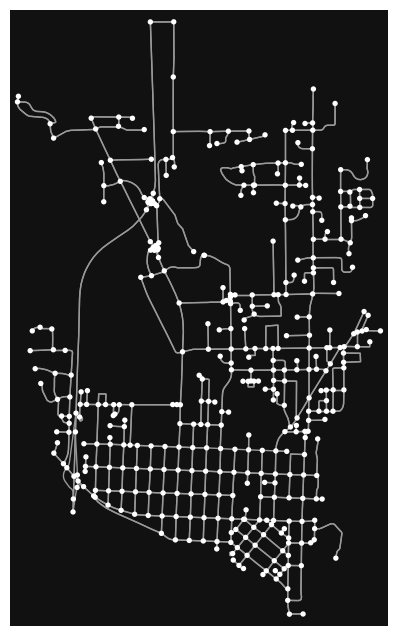

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [6]:
ox.plot_graph(G)


In [7]:
list(G.nodes(data=True))[0]

(50607534, {'y': 47.9334204, 'x': -122.0823321, 'street_count': 3})

In [8]:
ox.settings.elevation_url_template = (
    "https://api.opentopodata.org/v1/aster30m?locations={locations}"
)
G = ox.elevation.add_node_elevations_google(G, batch_size=100, pause=1)
G = ox.elevation.add_edge_grades(G)
print(list(G.nodes(data=True))[0])
print(list(G.edges(data=True))[0])

(50607534, {'y': 47.9334204, 'x': -122.0823321, 'street_count': 3, 'elevation': 62.0})
(50607534, 50607543, {'osmid': 6132413, 'highway': 'residential', 'name': 'Terrace Avenue', 'oneway': False, 'reversed': False, 'length': np.float64(113.30820412501359), 'grade': np.float64(0.05295291763145558), 'grade_abs': np.float64(0.05295291763145558)})


In [9]:
gdf_nodes, gdf_edges = ox.convert.graph_to_gdfs(G)
print(gdf_nodes.shape)
print(gdf_edges.shape)
gdf_edges.head()

(416, 6)
(1057, 15)


osmid      highway            name  oneway  \
u        v           key                                                    
50607534 50607543    0       6132413  residential  Terrace Avenue   False   
         50740099    0       6132413  residential  Terrace Avenue   False   
         12385935615 0    1339009305  residential             NaN   False   
50607543 50607534    0       6132413  residential  Terrace Avenue   False   
         50719959    0       6132413  residential  Terrace Avenue   False   

                         reversed      length     grade  grade_abs  \
u        v           key                                             
50607534 50607543    0      False  113.308204  0.052953   0.052953   
         50740099    0       True  236.807250  0.050674   0.050674   
         12385935615 0       True   67.615388  0.073948   0.073948   
50607543 50607534    0       True  113.308204 -0.052953   0.052953   
         50719959    0      False  159.779829  0.037552   0.037552   

                                                                   geometry  \
u        v           key                                                      
50607534 50607543    0    LINESTRING (-122.08233 47.93342, -122.08235 47...   
         50740099    0    LINESTRING (-122.08233 47.93342, -122.08231 47...   
         12385935615 0    LINESTRING (-122.08233 47.93342, -122.08156 47...   
50607543 50607534    0    LINESTRING (-122.08235 47.93444, -122.08233 47...   
         50719959    0    LINESTRING (-122.08235 47.93444, -122.08236 47...   

                         lanes maxspeed  ref bridge area junction  
u        v           key                                           
50607534 50607543    0     NaN      NaN  NaN    NaN  NaN      NaN  
         50740099    0     NaN      NaN  NaN    NaN  NaN      NaN  
         12385935615 0     NaN      NaN  NaN    NaN  NaN      NaN  
50607543 50607534    0     NaN      NaN  NaN    NaN  NaN      NaN  
         50719959    0     NaN      NaN  NaN    NaN  NaN      NaN

In [10]:
gdf_edges.index[0]

(np.int64(50607534), np.int64(50607543), np.int64(0))

In [11]:
gdf_edges['maxspeed'].isnull().sum()

np.int64(859)

In [12]:
print(gdf_edges['highway'].unique())
print(gdf_edges['highway'].isnull().sum())

<StringArray>
[  'residential',     'secondary',      'tertiary',  'primary_link',
       'primary',  'unclassified', 'living_street']
Length: 7, dtype: str
0


<Axes: >

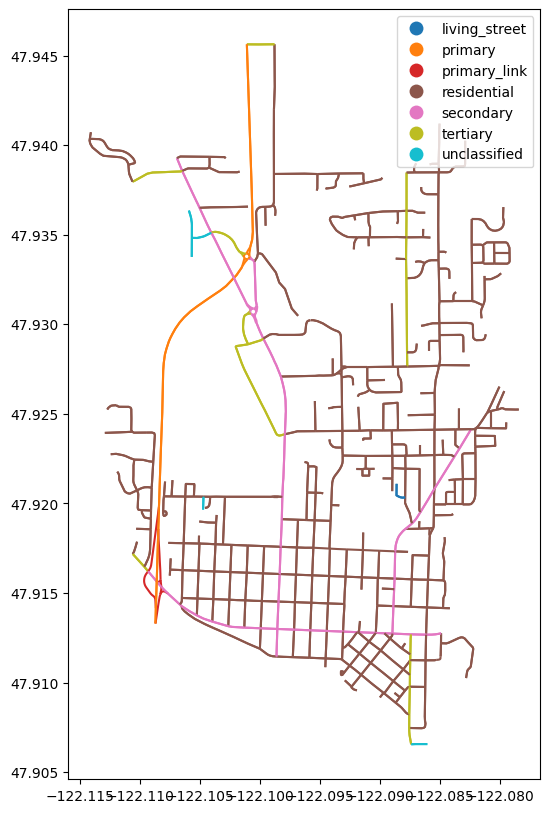

In [13]:
gdf_edges.plot(column='highway', figsize=(10, 10), legend=True)

In [14]:
gdf_edges['maxspeed'].dropna().unique()
gdf_edges['maxspeed'].dropna().head()

u         v           key
50632299  50651719    0      25 mph
          1499469272  0      25 mph
50633205  50796870    0      25 mph
          50651713    0      25 mph
50651713  50633205    0      25 mph
Name: maxspeed, dtype: str

In [15]:
default_speed = {
    'residential': '25',
    'secondary': '30',
    'tertiary': '35' ,
    'primary_link': '40',
    'primary': '45',
    'unclassified': '25',
    'living_street': '10'
}
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].fillna(gdf_edges['highway'].map(default_speed))
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].str.replace(' mph', '',regex=False)
gdf_edges['maxspeed'] = gdf_edges['maxspeed'].astype(int)
gdf_edges.head()

osmid      highway            name  oneway  \
u        v           key                                                    
50607534 50607543    0       6132413  residential  Terrace Avenue   False   
         50740099    0       6132413  residential  Terrace Avenue   False   
         12385935615 0    1339009305  residential             NaN   False   
50607543 50607534    0       6132413  residential  Terrace Avenue   False   
         50719959    0       6132413  residential  Terrace Avenue   False   

                         reversed      length     grade  grade_abs  \
u        v           key                                             
50607534 50607543    0      False  113.308204  0.052953   0.052953   
         50740099    0       True  236.807250  0.050674   0.050674   
         12385935615 0       True   67.615388  0.073948   0.073948   
50607543 50607534    0       True  113.308204 -0.052953   0.052953   
         50719959    0      False  159.779829  0.037552   0.037552   

                                                                   geometry  \
u        v           key                                                      
50607534 50607543    0    LINESTRING (-122.08233 47.93342, -122.08235 47...   
         50740099    0    LINESTRING (-122.08233 47.93342, -122.08231 47...   
         12385935615 0    LINESTRING (-122.08233 47.93342, -122.08156 47...   
50607543 50607534    0    LINESTRING (-122.08235 47.93444, -122.08233 47...   
         50719959    0    LINESTRING (-122.08235 47.93444, -122.08236 47...   

                         lanes  maxspeed  ref bridge area junction  
u        v           key                                            
50607534 50607543    0     NaN        25  NaN    NaN  NaN      NaN  
         50740099    0     NaN        25  NaN    NaN  NaN      NaN  
         12385935615 0     NaN        25  NaN    NaN  NaN      NaN  
50607543 50607534    0     NaN        25  NaN    NaN  NaN      NaN  
         50719959    0     NaN        25  NaN    NaN  NaN      NaN

In [16]:
gdf_edges['maxspeed'].isnull().sum()
gdf_edges['maxspeed'].dtype

dtype('int64')

In [17]:
import shapely as shp
import math
help(math.atan2)

Help on built-in function atan2 in module math:

atan2(y, x, /)
    Return the arc tangent (measured in radians) of y/x.

    Unlike atan(y/x), the signs of both x and y are considered.



In [18]:
from shapely import LineString


def compute_curvature(LineString):

    x, y = LineString.coords.xy
    currX = None
    currY = None
    bearing = 0
    prevbearing = None
    currbearing = None
    for n in range(len(x)):
        if n == 0:
            currX = x[n]
            currY = y[n]
        elif prevbearing is None:
            nextX = x[n]
            nextY = y[n]
            prevbearing = math.atan2(nextY - currY, nextX - currX)
            currX = nextX
            currY = nextY
        else:
            nextX = x[n]
            nextY = y[n]
            currbearing = math.atan2(nextY - currY, nextX - currX)
            diffBearing = abs(currbearing - prevbearing)
            diffBearing = min(diffBearing, math.pi)
            bearing = diffBearing - (math.pi*2) + bearing if diffBearing > math.pi else diffBearing + bearing
            prevbearing = currbearing
            currX = nextX
            currY = nextY

    return bearing
test_geom = gdf_edges['geometry'].iloc[0]
print(test_geom)
compute_curvature(test_geom)
for x in gdf_edges['geometry']:
    print(compute_curvature(x))
        

LINESTRING (-122.0823321 47.9334204, -122.0823538 47.9344393)
0
0
0.3421488007502699
0
0.037194583697084616
0.4028273909481441
0.1353860417644055
6.336949739872651
0.16199388787551217
0.13538604176440572
0.00024615702582092905
3.158272289247135
0.08938916978312172
0.48472142730502876
0.3722457645987287
0.29566711862965533
0.2734102685241875
0.2274032859792129
3.391655904385126
0.05561150311186491
0
3.4817444239268465
0.001521202842029279
0
4.720083926601504e-05
2.949266677737268
0.030453337096118638
0.030061973746978055
0.08472585804327193
0
0.0007635530127945156
0.6744853964401389
1.6362989983300147
1.368848424450557
0.2082997699608562
0
0.142583053500269
0.0002904278782542846
0.1118117466475117
0.5814164013471437
0.05561150311186491
1.9035629984662912
0.6983581440533206
0.37224576459872916
0.2767029236630306
0.1177308637671417
0.059849407397063514
1.2569974754172628
1.6245299692386275
0.00026113663667048925
1.256997475417263
0.2545775442255126
0.35463918915783416
0.25457754422551293


In [19]:
gdf_edges['curvature'] = gdf_edges['geometry'].apply(compute_curvature)
gdf_edges['curvature'].idxmax()

(np.int64(50758769), np.int64(50768133), np.int64(0))

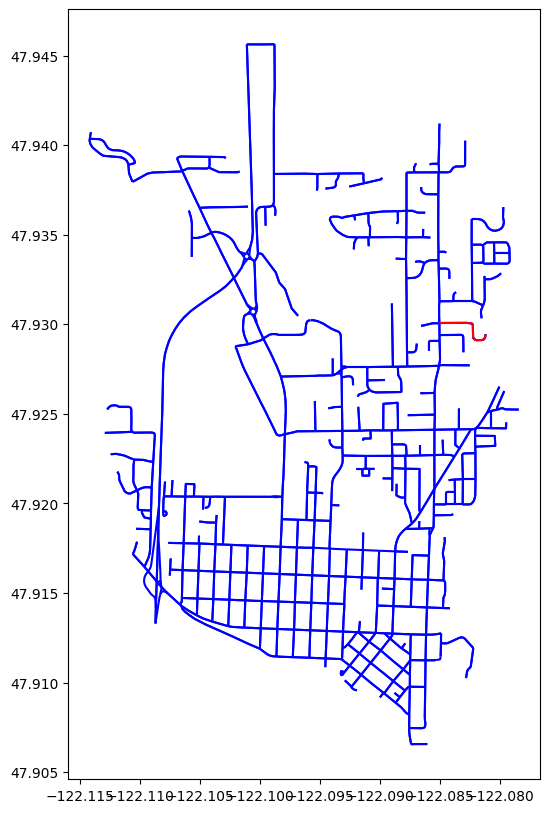

In [20]:
import matplotlib.pyplot as plt
max_curve =gdf_edges[gdf_edges['curvature'] == gdf_edges['curvature'].max()]
fig, ax = plt.subplots(figsize=(10, 10))
gdf_edges.plot(ax =ax, color='blue', legend=True)
max_curve.plot(ax=ax, color='red', label='Max Curvature')
plt.show()




<Axes: >

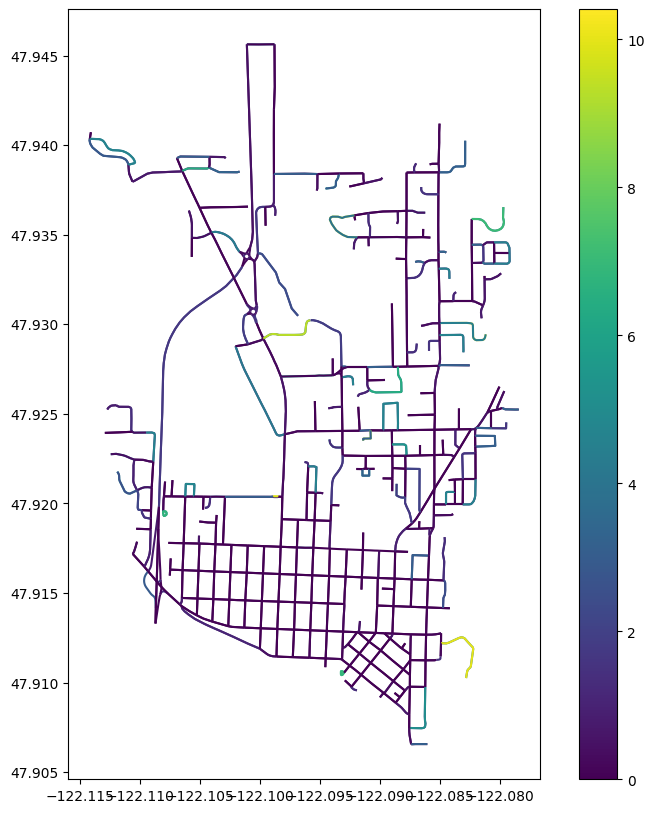

In [21]:
gdf_edges.plot(column='curvature', figsize=(10, 10), legend=True)

In [22]:
gdf_nodes.head()

,y,x,street_count,elevation,highway,geometry
osmid,,,,,,
50607534,47.933420,-122.082332,3,62.0,NaN,POINT (-122.08233 47.93342)
50607543,47.934439,-122.082354,3,68.0,NaN,POINT (-122.08235 47.93444)
50617706,47.928093,-122.093932,1,31.0,NaN,POINT (-122.09393 47.92809)
50617714,47.927151,-122.093925,3,36.0,NaN,POINT (-122.09393 47.92715)
50628349,47.918590,-122.086730,3,15.0,NaN,POINT (-122.08673 47.91859)


In [23]:
gdf_edges.head()

osmid      highway            name  oneway  \
u        v           key                                                    
50607534 50607543    0       6132413  residential  Terrace Avenue   False   
         50740099    0       6132413  residential  Terrace Avenue   False   
         12385935615 0    1339009305  residential             NaN   False   
50607543 50607534    0       6132413  residential  Terrace Avenue   False   
         50719959    0       6132413  residential  Terrace Avenue   False   

                         reversed      length     grade  grade_abs  \
u        v           key                                             
50607534 50607543    0      False  113.308204  0.052953   0.052953   
         50740099    0       True  236.807250  0.050674   0.050674   
         12385935615 0       True   67.615388  0.073948   0.073948   
50607543 50607534    0       True  113.308204 -0.052953   0.052953   
         50719959    0      False  159.779829  0.037552   0.037552   

                                                                   geometry  \
u        v           key                                                      
50607534 50607543    0    LINESTRING (-122.08233 47.93342, -122.08235 47...   
         50740099    0    LINESTRING (-122.08233 47.93342, -122.08231 47...   
         12385935615 0    LINESTRING (-122.08233 47.93342, -122.08156 47...   
50607543 50607534    0    LINESTRING (-122.08235 47.93444, -122.08233 47...   
         50719959    0    LINESTRING (-122.08235 47.93444, -122.08236 47...   

                         lanes  maxspeed  ref bridge area junction  curvature  
u        v           key                                                       
50607534 50607543    0     NaN        25  NaN    NaN  NaN      NaN   0.000000  
         50740099    0     NaN        25  NaN    NaN  NaN      NaN   0.000000  
         12385935615 0     NaN        25  NaN    NaN  NaN      NaN   0.342149  
50607543 50607534    0     NaN        25  NaN    NaN  NaN      NaN   0.000000  
         50719959    0     NaN        25  NaN    NaN  NaN      NaN   0.037195

In [24]:
import pandas as pd
df_edges_matrix = gdf_edges[['length', 'maxspeed', 'grade','grade_abs', 'curvature','highway']]
df_highway_dummies = pd.get_dummies(df_edges_matrix['highway'], prefix='highway', drop_first =True)
df_edges_matrix.drop('highway', axis=1, inplace=True)
df_edges_matrix = pd.concat([df_edges_matrix, df_highway_dummies], axis=1)
print(df_edges_matrix.shape)
print(df_edges_matrix.isnull().sum())


(1057, 11)
length                  0
maxspeed                0
grade                   0
grade_abs               0
curvature               0
highway_primary         0
highway_primary_link    0
highway_residential     0
highway_secondary       0
highway_tertiary        0
highway_unclassified    0
dtype: int64


In [25]:
for u, v, d in G.edges(data=True):
      print(u, v, d)
      break

50607534 50607543 {'osmid': 6132413, 'highway': 'residential', 'name': 'Terrace Avenue', 'oneway': False, 'reversed': False, 'length': np.float64(113.30820412501359), 'grade': np.float64(0.05295291763145558), 'grade_abs': np.float64(0.05295291763145558)}


In [26]:
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break

['osmid', 'highway', 'name', 'oneway', 'reversed', 'length', 'grade', 'grade_abs']


In [27]:
G = ox.graph_from_gdfs(gdf_nodes, gdf_edges)
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break

['osmid', 'highway', 'name', 'oneway', 'reversed', 'length', 'grade', 'grade_abs', 'geometry', 'maxspeed', 'curvature']


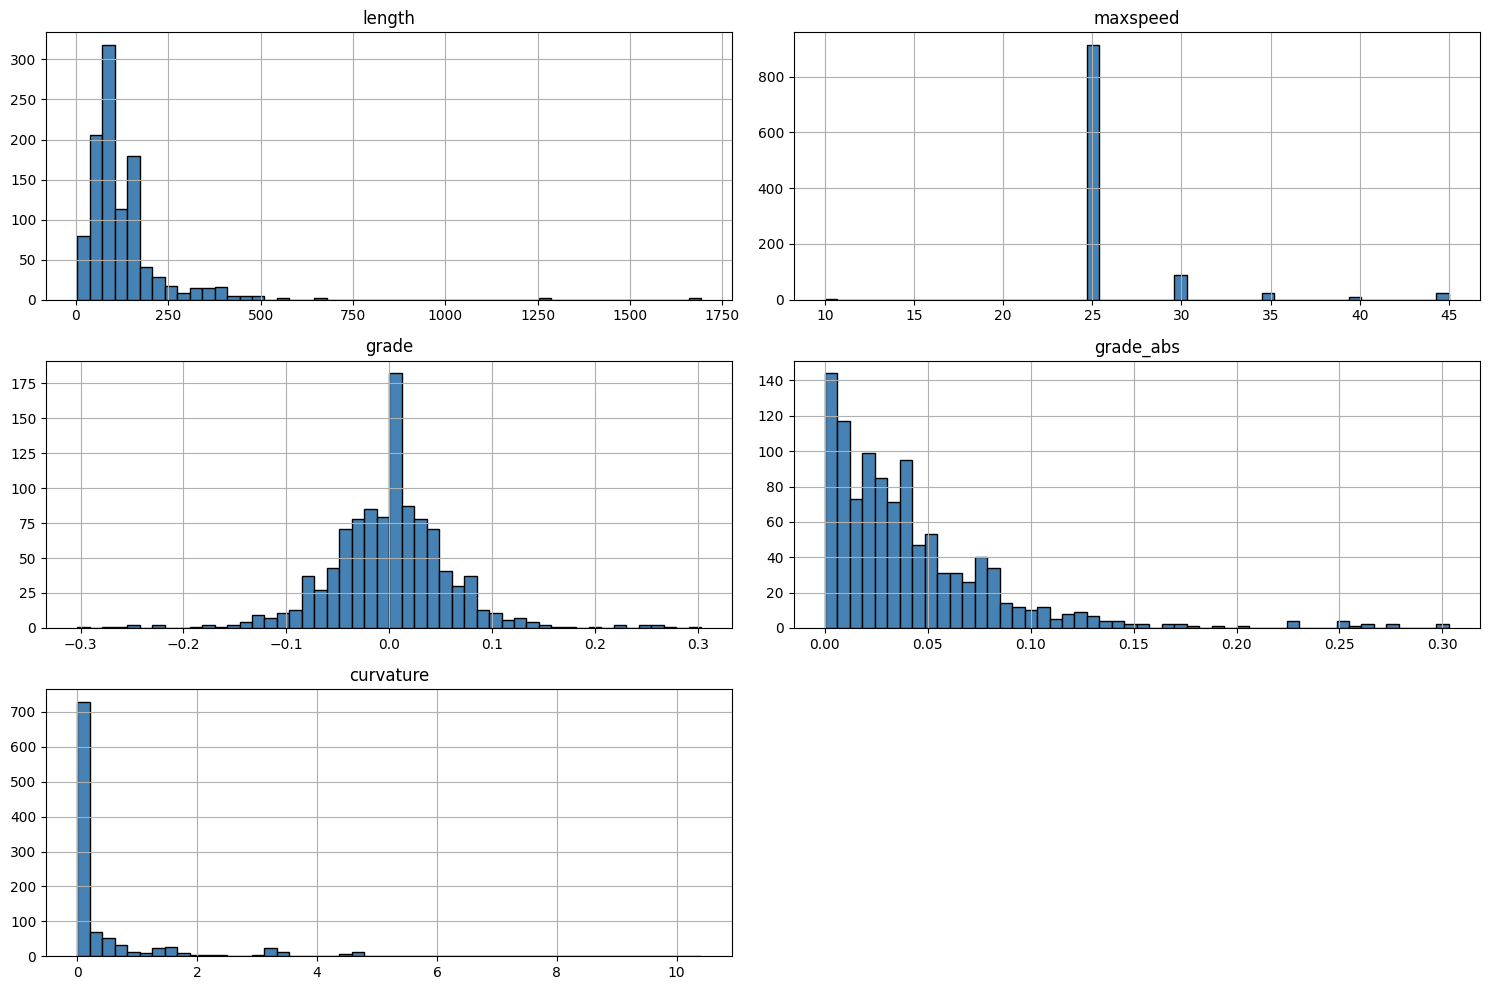

In [28]:
df_edges_matrix.hist(
    figsize=(15, 10), 
    bins=50, 
    color='steelblue', 
    edgecolor='black'
)

# This prevents the subplot titles from overlapping
plt.tight_layout() 

plt.show()

<Axes: >

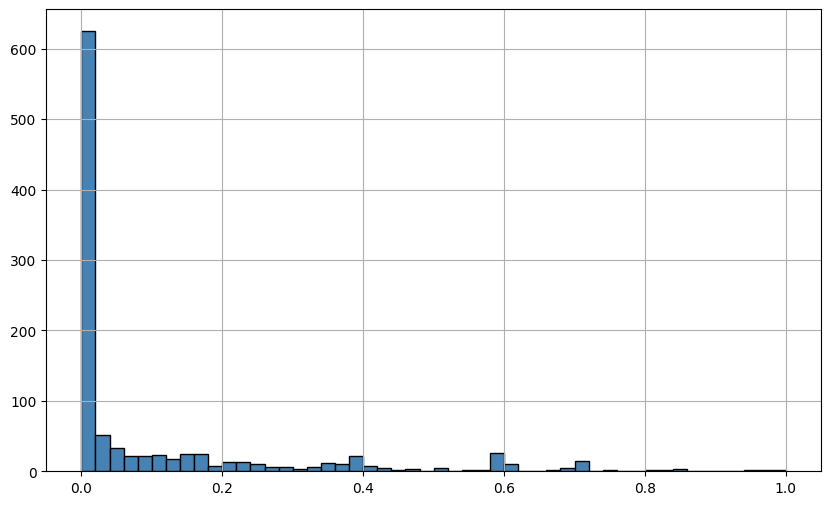

In [29]:
import numpy as np
normalized_gdf_edges = gdf_edges.copy()
normalized_gdf_edges['curvature'] = np.log1p(normalized_gdf_edges['curvature'])
n_min = normalized_gdf_edges['curvature'].min()
n_max = normalized_gdf_edges['curvature'].max()
normalized_gdf_edges['curvature'] = (normalized_gdf_edges['curvature'] - n_min) / (n_max - n_min)
normalized_gdf_edges['curvature'].hist(
    figsize=(10, 6), 
    bins=50, 
    color='steelblue', 
    edgecolor='black'
)

<Axes: >

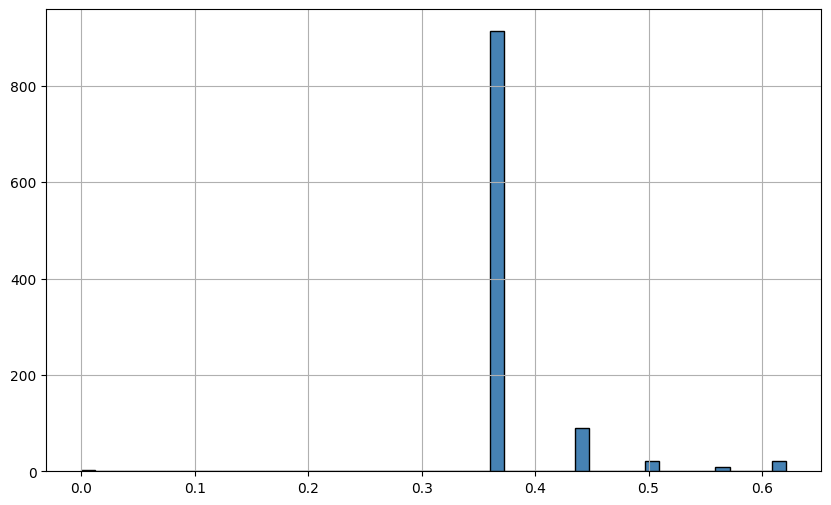

In [30]:
# 10 is a minimum speed limit and 85 is a maximum speed limit
#0.625 gives an exponential distribution with 35mp being the center
normalized_gdf_edges['maxspeed'] = ((normalized_gdf_edges['maxspeed'] - 10) / (85 - 10) )** 0.625 
normalized_gdf_edges['maxspeed'].hist(
    figsize=(10, 6), 
    bins=50, 
    color='steelblue', 
    edgecolor='black'
)

<Axes: >

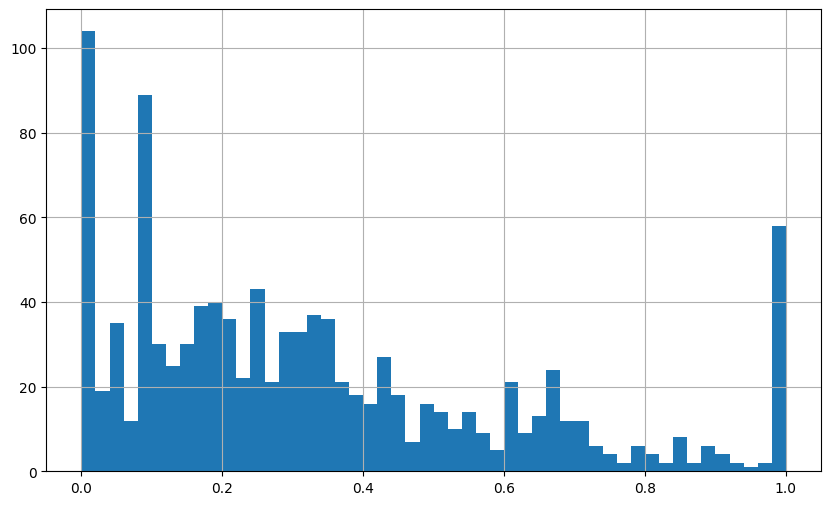

In [31]:
lower_bounds = normalized_gdf_edges['grade_abs'].quantile(0.05)
higher_bounds = normalized_gdf_edges['grade_abs'].quantile(0.95)

normalized_gdf_edges['grade_abs'] = normalized_gdf_edges['grade_abs'].clip(lower=lower_bounds, upper=higher_bounds)
min_grade = normalized_gdf_edges['grade_abs'].min()
max_grade = normalized_gdf_edges['grade_abs'].max()
normalized_gdf_edges['grade_abs'] = (normalized_gdf_edges['grade_abs'] - min_grade) / (max_grade - min_grade)
normalized_gdf_edges['grade_abs'].hist(
    figsize=(10, 6),
    bins=50
)

<Axes: >

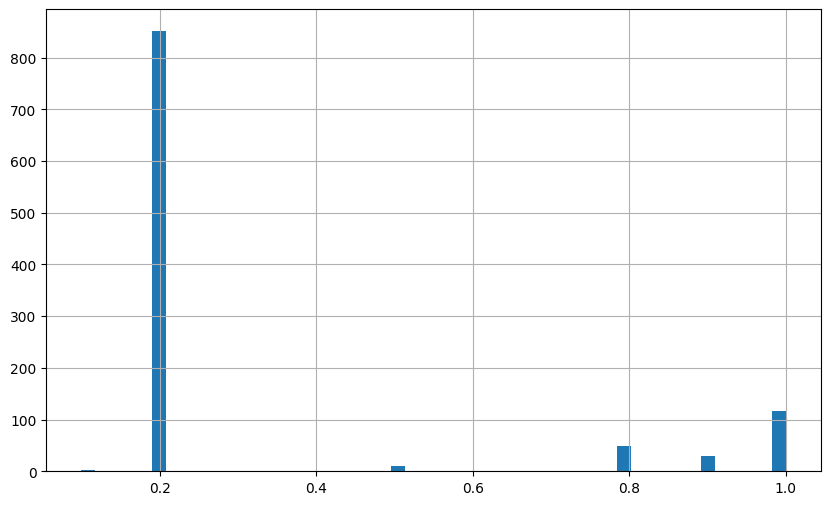

In [32]:
highway_penalties = {
    'residential': 0.2,
    'secondary': 1.0,
    'tertiary': 0.8,
    'primary_link': 0.9,
    'primary': 0.9,
    'unclassified': 0.5,
    'living_street': 0.1
}
normalized_gdf_edges['highway_penalty'] = normalized_gdf_edges['highway'].map(highway_penalties).fillna(1.0)
normalized_gdf_edges['highway_penalty'].hist(
    figsize=(10, 6),
    bins=50
)

In [33]:
G = ox.graph_from_gdfs(gdf_nodes, normalized_gdf_edges)
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break
normalized_gdf_edges.head()

['osmid', 'highway', 'name', 'oneway', 'reversed', 'length', 'grade', 'grade_abs', 'geometry', 'maxspeed', 'curvature', 'highway_penalty']


osmid      highway            name  oneway  \
u        v           key                                                    
50607534 50607543    0       6132413  residential  Terrace Avenue   False   
         50740099    0       6132413  residential  Terrace Avenue   False   
         12385935615 0    1339009305  residential             NaN   False   
50607543 50607534    0       6132413  residential  Terrace Avenue   False   
         50719959    0       6132413  residential  Terrace Avenue   False   

                         reversed      length     grade  grade_abs  \
u        v           key                                             
50607534 50607543    0      False  113.308204  0.052953   0.447946   
         50740099    0       True  236.807250  0.050674   0.428669   
         12385935615 0       True   67.615388  0.073948   0.625548   
50607543 50607534    0       True  113.308204 -0.052953   0.447946   
         50719959    0      False  159.779829  0.037552   0.317662   

                                                                   geometry  \
u        v           key                                                      
50607534 50607543    0    LINESTRING (-122.08233 47.93342, -122.08235 47...   
         50740099    0    LINESTRING (-122.08233 47.93342, -122.08231 47...   
         12385935615 0    LINESTRING (-122.08233 47.93342, -122.08156 47...   
50607543 50607534    0    LINESTRING (-122.08235 47.93444, -122.08233 47...   
         50719959    0    LINESTRING (-122.08235 47.93444, -122.08236 47...   

                         lanes  maxspeed  ref bridge area junction  curvature  \
u        v           key                                                        
50607534 50607543    0     NaN  0.365716  NaN    NaN  NaN      NaN   0.000000   
         50740099    0     NaN  0.365716  NaN    NaN  NaN      NaN   0.000000   
         12385935615 0     NaN  0.365716  NaN    NaN  NaN      NaN   0.120886   
50607543 50607534    0     NaN  0.365716  NaN    NaN  NaN      NaN   0.000000   
         50719959    0     NaN  0.365716  NaN    NaN  NaN      NaN   0.015002   

                          highway_penalty  
u        v           key                   
50607534 50607543    0                0.2  
         50740099    0                0.2  
         12385935615 0                0.2  
50607543 50607534    0                0.2  
         50719959    0                0.2

In [34]:
def fun_score(u,v,d):
    score = 0
    d = d[0]
    score += d['maxspeed'] * 0.3
    score += d['grade_abs'] * 0.1
    score += d['curvature'] * 0.4
    score += d['highway_penalty'] * 0.2
    return (1 - score) * d['length']
    

In [35]:
import networkx as nx
nx.dijkstra_path(G, 50607534, 50607543, weight=fun_score)

[50607534, 50607543]

In [36]:
G.nodes[50607534]

{'y': 47.9334204, 'x': -122.0823321, 'street_count': 3, 'elevation': 62.0}

In [38]:
for u, v, d in G.edges(data=True):
      print(list(d.keys()))
      break
print(normalized_gdf_edges['curvature'].isnull().sum())
print(gdf_edges['curvature'].isnull().sum())
if normalized_gdf_edges['curvature'].isnull:
    print(normalized_gdf_edges['geometry'])
print(gdf_edges['curvature'].min())

['osmid', 'highway', 'name', 'oneway', 'reversed', 'length', 'grade', 'grade_abs', 'geometry', 'maxspeed', 'curvature', 'highway_penalty']
0
0
u            v            key
50607534     50607543     0      LINESTRING (-122.08233 47.93342, -122.08235 47...
             50740099     0      LINESTRING (-122.08233 47.93342, -122.08231 47...
             12385935615  0      LINESTRING (-122.08233 47.93342, -122.08156 47...
50607543     50607534     0      LINESTRING (-122.08235 47.93444, -122.08233 47...
             50719959     0      LINESTRING (-122.08235 47.93444, -122.08236 47...
                                                       ...                        
12385935618  12385935616  0      LINESTRING (-122.08048 47.93398, -122.08049 47...
             12385935619  0      LINESTRING (-122.08048 47.93398, -122.0792 47....
12385935619  12385935618  0      LINESTRING (-122.0792 47.93398, -122.08048 47....
             12385935617  0      LINESTRING (-122.0792 47.93398, -122.07919 47..

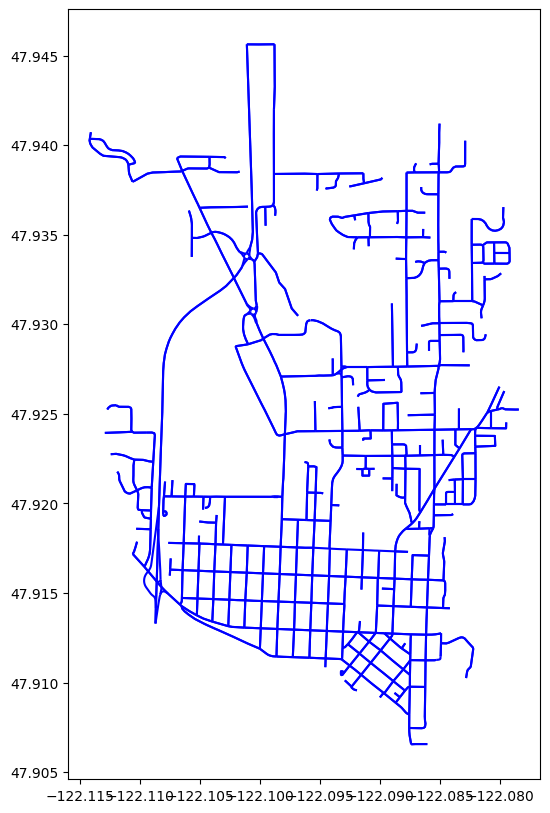

In [40]:
null_curve = normalized_gdf_edges[normalized_gdf_edges['curvature'].isnull()]
fig, ax = plt.subplots(figsize=(10, 10))
normalized_gdf_edges.plot(ax=ax, color='blue', legend=True)

if not null_curve.empty:
	null_curve.plot(ax=ax, color='red', label='Null Curvature')

plt.show()

In [50]:
distance, path = nx.single_source_dijkstra(G, 50607534, cutoff= 6000, weight="length")
filter_distance_dict = {k: v for k, v in distance.items() if v >= 2000 and v < 5000}
print(filter_distance_dict)
len(filter_distance_dict)

{50768687: 2026.7674440252642, 50742038: 2027.7577119682687, 50742071: 2076.3483522348815, 50633205: 2096.780807786897, 50742069: 2156.3474182584964, 50797418: 2166.9494306348934, 50797526: 2172.004870108414, 50739531: 2177.579422375132, 50798062: 2198.1980910575794, 50651713: 2203.35680547965, 50739535: 2245.491890215053, 3276115369: 2261.514809499032, 50684895: 2273.8786313509863, 3276115371: 2274.057292088554, 50710479: 2277.4251166534063, 50712813: 2278.4653044308575, 7086240031: 2289.9232721673834, 3276115420: 2300.9575046262844, 3276115376: 2304.496119128427, 6370340048: 2310.8884668895694, 50651719: 2316.3110739530475, 3276115380: 2328.5670108618874, 3276115381: 2332.4059564045374, 7086240028: 2340.091557036203, 3276115364: 2346.79676622977, 50675322: 2349.4245669445936, 50739537: 2349.7618199762496, 3276115365: 2353.0381509860094, 1499469298: 2354.505839196109, 3289224869: 2358.6785338165714, 6370340049: 2386.900666835571, 50649831: 2388.606007404516, 50675317: 2416.41749918938

247

In [53]:
nx.single_source_dijkstra(G, 50607534, cutoff= 6000, weight="length")
distance_fun, path_fun = nx.single_source_dijkstra(G, 50607534, weight=fun_score) 
min(filter_distance_dict, key=lambda n: distance_fun[n]) 

50633205

In [54]:
print(path_fun[50633205])

[50607534, 50740099, 50698714, 50768136, 50768133, 50768129, 50768125, 50768122, 50677337, 1973286575, 50764814, 50692690, 2747760970, 50796881, 50796876, 50617714, 50796870, 50633205]


In [58]:
return_path = nx.dijkstra_path(G,50633205 , 50607534, weight=fun_score)
print(return_path)

[50633205, 50796870, 50617714, 50796876, 50796881, 2747760970, 50692690, 50764814, 1973286575, 50677337, 50768122, 50768125, 50768129, 50768133, 50768136, 50698714, 50740099, 50607534]


In [60]:
round_trip = path_fun[50633205] + return_path[1:]
print(round_trip)

[50607534, 50740099, 50698714, 50768136, 50768133, 50768129, 50768125, 50768122, 50677337, 1973286575, 50764814, 50692690, 2747760970, 50796881, 50796876, 50617714, 50796870, 50633205, 50796870, 50617714, 50796876, 50796881, 2747760970, 50692690, 50764814, 1973286575, 50677337, 50768122, 50768125, 50768129, 50768133, 50768136, 50698714, 50740099, 50607534]


In [70]:
# .loc[row_label, column_label]
lat = gdf_nodes.loc[round_trip, 'y'].values
lon = gdf_nodes.loc[round_trip, 'x'].values
lat_lon = list(zip(lat, lon)) 
print(lat_lon)


[(np.float64(47.9334204), np.float64(-122.0823321)), (np.float64(47.9312908), np.float64(-122.0823091)), (np.float64(47.9312908), np.float64(-122.0838865)), (np.float64(47.9312842), np.float64(-122.0850353)), (np.float64(47.930063), np.float64(-122.0850448)), (np.float64(47.9293984), np.float64(-122.085033)), (np.float64(47.9290721), np.float64(-122.0850272)), (np.float64(47.9276799), np.float64(-122.0851059)), (np.float64(47.9276403), np.float64(-122.0877207)), (np.float64(47.9276301), np.float64(-122.0885026)), (np.float64(47.927629), np.float64(-122.088913)), (np.float64(47.9276136), np.float64(-122.0910529)), (np.float64(47.9276136), np.float64(-122.092748)), (np.float64(47.9274776), np.float64(-122.0931996)), (np.float64(47.9272477), np.float64(-122.0936116)), (np.float64(47.9271514), np.float64(-122.0939254)), (np.float64(47.9270817), np.float64(-122.0982484)), (np.float64(47.9292033), np.float64(-122.0997113)), (np.float64(47.9270817), np.float64(-122.0982484)), (np.float64(47.9

In [81]:
import folium
m = folium.Map(location=[47.9334204, -122.0823321], zoom_start=11)
folium.PolyLine(lat_lon, tooltip="Road").add_to(m)
m.save('round_trip_map.html')